In [1]:
import os

project_root = os.path.dirname(os.getcwd())
report_path = os.path.join(project_root, "reports")
os.makedirs(report_path, exist_ok=True)

## 1️⃣ Import Libraries

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Advanced models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model saving
import joblib

## 2️⃣ Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("D:/Desktop/B13-ExoHabitAI/data/preprocessed/preprocessed.csv")

df.head()

,Planet_Name,Planet_Radius,Planet_Mass,Orbital_Period,Semi_Major_Axis,Equilibrium_Temp,Planet_Density,Stellar_Temp,Stellar_Luminosity,Stellar_Metallicity,Habitability_Score_Index,Stellar_Compatibility_Index,Orbital_Stability_Factor,StarType_A,StarType_F,StarType_G,StarType_K,StarType_M,Target_Habitable
0,CoRoT-1 b,16.70,327.35000,1.508956,0.054235,1898.0,0.380,5950.0,0.941261,-0.30,0.057038,0.993447,0.948652,False,False,True,False,False,0
1,CoRoT-10 b,10.87,762.44317,13.240600,0.105500,600.0,3.700,5075.0,0.941261,0.26,0.136704,0.895992,0.048838,False,False,False,True,False,1
2,CoRoT-11 b,16.03,740.51000,2.994330,0.043600,1657.0,0.990,6440.0,0.941261,-0.03,0.051958,0.907204,0.089835,False,True,False,False,False,0
3,CoRoT-12 b,16.14,291.43800,2.828042,0.040160,1442.0,0.411,5675.0,0.941261,0.16,0.051044,0.997645,0.033059,False,False,False,True,False,0
4,CoRoT-13 b,9.92,415.70400,4.035190,0.051000,1700.0,2.340,5945.0,0.941261,0.01,0.066387,0.993822,0.035881,False,False,True,False,False,0


## 3️⃣ Separate Features & Target

In [4]:
target_column = "Target_Habitable"

X = df.drop(columns=[
    "Target_Habitable",
    "Planet_Name",
    "Habitability_Score_Index",
    "Stellar_Compatibility_Index",
    "Orbital_Stability_Factor"
])

y = df[target_column]

## 4️⃣ Train-Test Split (80–20)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (792, 14)
Testing shape: (199, 14)


## 5️⃣ Create Evaluation Function (Reusable)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {model_name} Evaluation =====")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    # -------------------------
    # Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(os.path.join(report_path, f"{model_name}_confusion_matrix.png"))
    plt.show()

    # -------------------------
    # ROC Curve
    # -------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.savefig(os.path.join(report_path, f"{model_name}_roc_curve.png"))
    plt.show()

## 6️⃣ Baseline Model 1 – Logistic Regression


===== Logistic Regression Evaluation =====
Accuracy: 0.9597989949748744
Precision: 0.9509803921568627
Recall: 0.97
F1 Score: 0.9603960396039604
ROC-AUC: 0.9958585858585859

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        99
           1       0.95      0.97      0.96       100

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



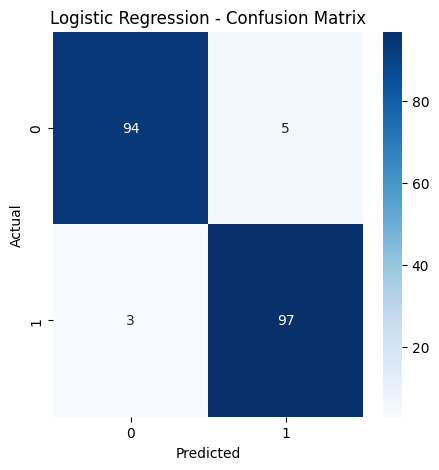

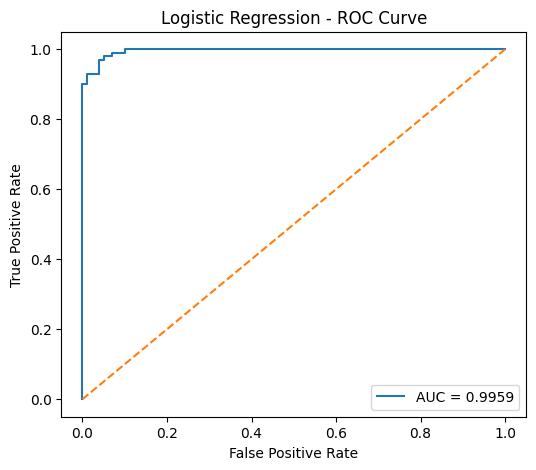

In [7]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)
evaluate_model(logistic_pipeline, X_test, y_test, "Logistic Regression")

## 7️⃣ Baseline Model 2 – Decision Tree (Shallow)


===== Decision Tree Evaluation =====
Accuracy: 0.9447236180904522
Precision: 0.9320388349514563
Recall: 0.96
F1 Score: 0.9458128078817734
ROC-AUC: 0.9518686868686869

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        99
           1       0.93      0.96      0.95       100

    accuracy                           0.94       199
   macro avg       0.95      0.94      0.94       199
weighted avg       0.95      0.94      0.94       199



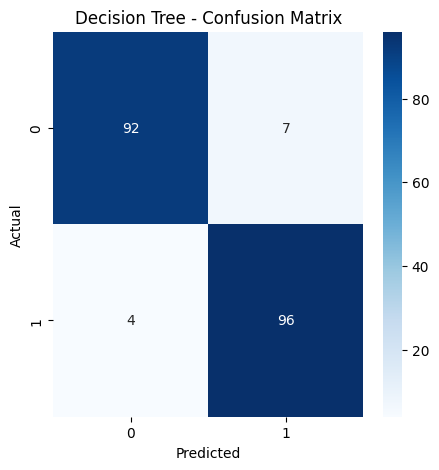

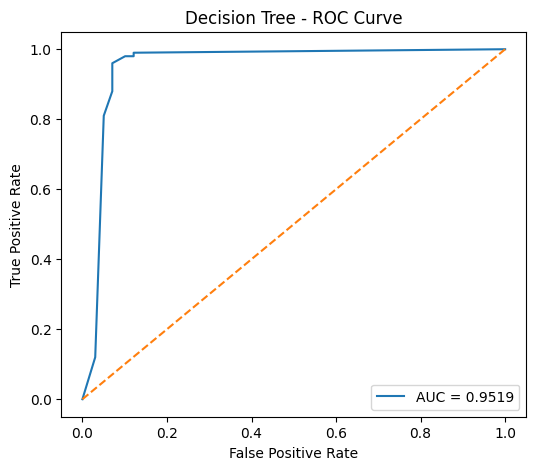

In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

evaluate_model(dt_model, X_test, y_test, "Decision Tree")

## 8️⃣ Primary Model – Random Forest


===== Random Forest Evaluation =====
Accuracy: 0.9597989949748744
Precision: 0.9509803921568627
Recall: 0.97
F1 Score: 0.9603960396039604
ROC-AUC: 0.9963131313131313

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        99
           1       0.95      0.97      0.96       100

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



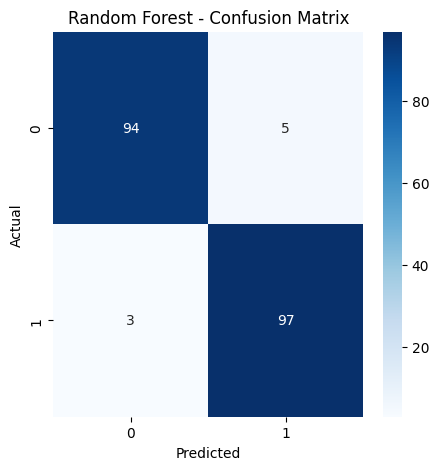

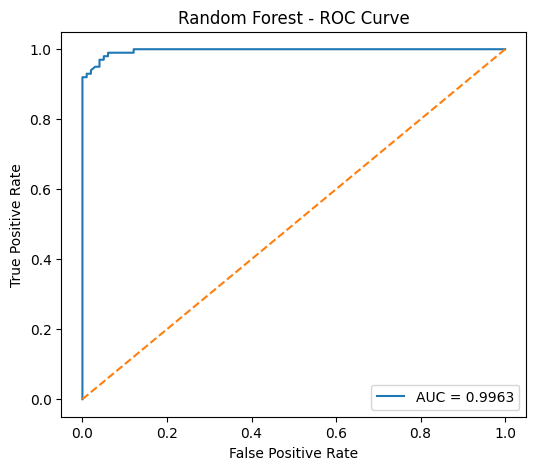

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test, "Random Forest")

## 9️⃣ Primary Model – XGBoost


===== XGBoost Evaluation =====
Accuracy: 0.9698492462311558
Precision: 0.9607843137254902
Recall: 0.98
F1 Score: 0.9702970297029703
ROC-AUC: 0.9968686868686869

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        99
           1       0.96      0.98      0.97       100

    accuracy                           0.97       199
   macro avg       0.97      0.97      0.97       199
weighted avg       0.97      0.97      0.97       199



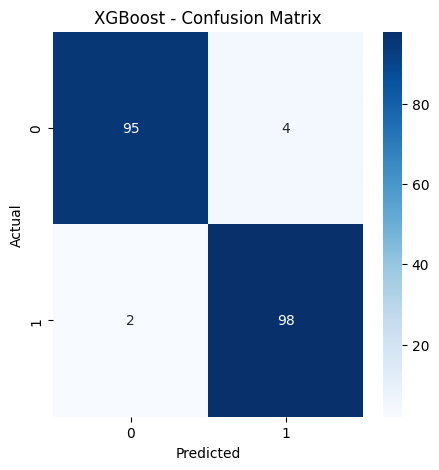

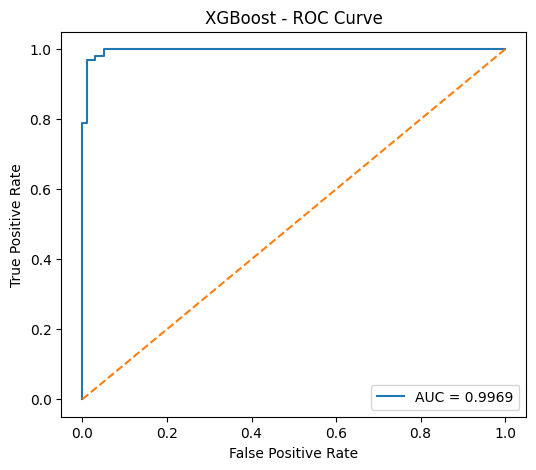

In [10]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")

## 🔟 Compare Models

In [11]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results = {
    "Logistic Regression": get_metrics(logistic_pipeline, X_test, y_test),
    "Decision Tree": get_metrics(dt_model, X_test, y_test),
    "Random Forest": get_metrics(rf_model, X_test, y_test),
    "XGBoost": get_metrics(xgb_model, X_test, y_test)
}

comparison_df = pd.DataFrame(results).T
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.959799,0.950980,0.97,0.960396,0.995859
Decision Tree,0.944724,0.932039,0.96,0.945813,0.951869
Random Forest,0.959799,0.950980,0.97,0.960396,0.996313
XGBoost,0.969849,0.960784,0.98,0.970297,0.996869


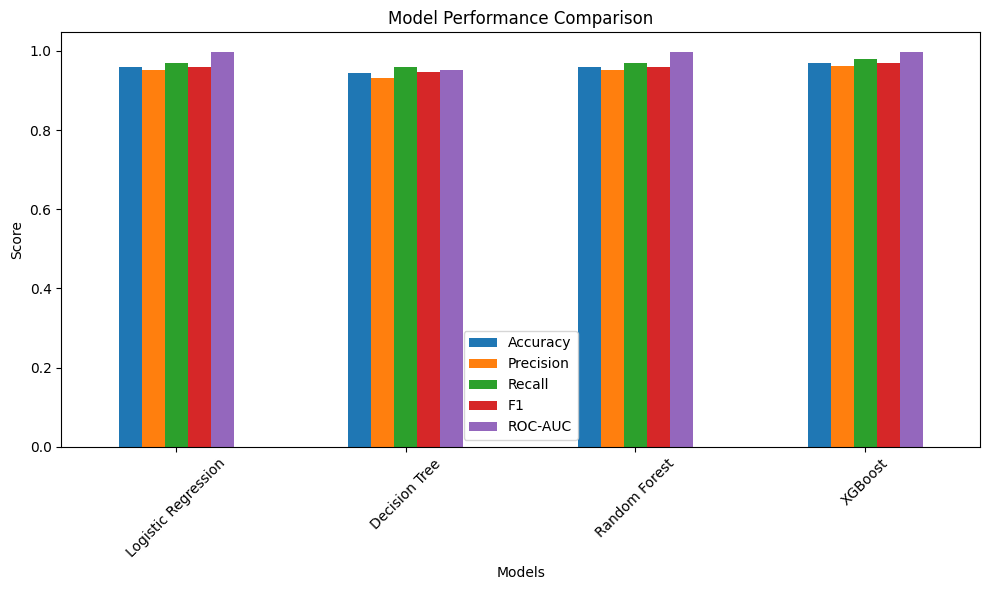

In [12]:
comparison_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(os.path.join(report_path, "model_comparison.png"))

plt.show()

## 10.2 Automatically Select Best Model

In [13]:
# Automatically select best model based on highest F1 score
best_model_name = comparison_df["F1"].idxmax()

print("Best model based on F1 score:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = logistic_pipeline
elif best_model_name == "Decision Tree":
    best_model = dt_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = xgb_model

Best model based on F1 score: XGBoost


## 1️⃣1️⃣ Save Best Model (Temporary)

In [14]:
import os
import joblib

save_path = "D:/Desktop/B13-ExoHabitAI/models"

os.makedirs(save_path, exist_ok=True)

joblib.dump(
    best_model,
    f"{save_path}/best_model.pkl"
)


['D:/Desktop/B13-ExoHabitAI/models/best_model.pkl']

In [15]:
# Retrain best model on full dataset before final deployment
best_model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

## 1️⃣2️⃣ Generate Habitability Score & Ranking

In [16]:
import os

# Create folder if not exists
save_dir = "D:/Desktop/B13-ExoHabitAI/data/processed"
os.makedirs(save_dir, exist_ok=True)

# Generate probability
df["Habitability_Probability"] = best_model.predict_proba(X)[:, 1]

# Sort
df_sorted = df.sort_values(by="Habitability_Probability", ascending=False)

# Save
df_sorted.to_csv(
    f"{save_dir}/habitability_ranked.csv",
    index=False
)

df_sorted.head()

,Planet_Name,Planet_Radius,Planet_Mass,Orbital_Period,Semi_Major_Axis,Equilibrium_Temp,Planet_Density,Stellar_Temp,Stellar_Luminosity,Stellar_Metallicity,Habitability_Score_Index,Stellar_Compatibility_Index,Orbital_Stability_Factor,StarType_A,StarType_F,StarType_G,StarType_K,StarType_M,Target_Habitable,Habitability_Probability
256,K2-222 b,2.350,8.70,15.388570,0.12060,871.0,3.680000,5942.0,0.941261,-0.315,0.208243,0.994041,0.005171,False,False,False,True,False,1,0.999592
741,TOI-411 c,2.328,9.72,9.573083,0.10170,931.0,3.150000,6169.0,0.941261,-0.080,0.183446,0.966597,0.184821,False,False,False,True,False,1,0.999592
156,HD 136352 b,1.664,4.72,11.577970,0.09640,905.0,5.623888,5664.0,1.038006,-0.240,0.185986,0.997116,0.049801,False,False,False,True,False,1,0.999584
172,HD 21749 c,0.892,3.70,7.789930,0.06950,701.0,6.818750,4640.0,0.271434,0.003,0.267806,0.749921,0.131594,False,False,False,True,False,1,0.999582
345,Kepler-107 e,2.903,14.10,14.749143,0.12638,955.0,3.180000,5854.0,0.941261,0.321,0.199370,0.998717,0.092631,False,False,False,True,False,1,0.999582


## 1️⃣3️⃣ Hyperparameter Tuning – Random Forest

Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

===== Tuned Random Forest Evaluation =====
Accuracy: 0.9597989949748744
Precision: 0.9509803921568627
Recall: 0.97
F1 Score: 0.9603960396039604
ROC-AUC: 0.9962626262626263

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        99
           1       0.95      0.97      0.96       100

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



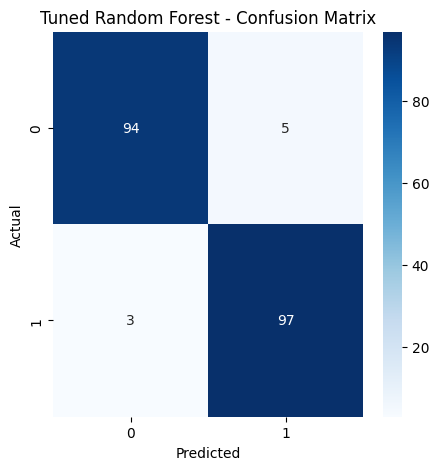

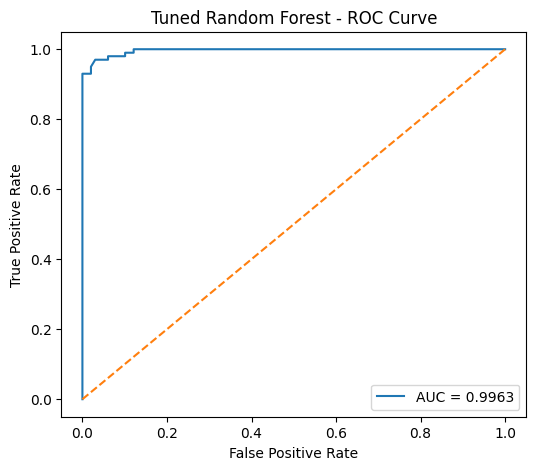

In [17]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Parameters:", rf_grid.best_params_)

evaluate_model(best_rf, X_test, y_test, "Tuned Random Forest")

## 1️⃣4️⃣ Hyperparameter Tuning – XGBoost

Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

===== Tuned XGBoost Evaluation =====
Accuracy: 0.9849246231155779
Precision: 0.9801980198019802
Recall: 0.99
F1 Score: 0.9850746268656716
ROC-AUC: 0.9981818181818182

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        99
           1       0.98      0.99      0.99       100

    accuracy                           0.98       199
   macro avg       0.98      0.98      0.98       199
weighted avg       0.98      0.98      0.98       199



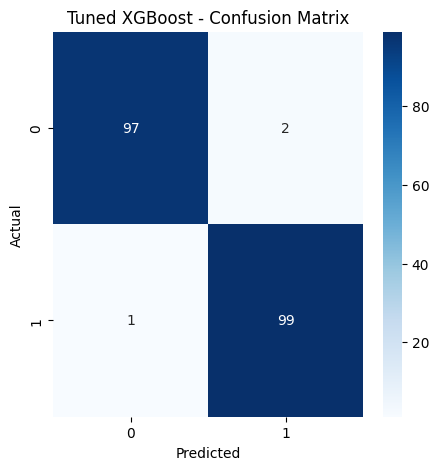

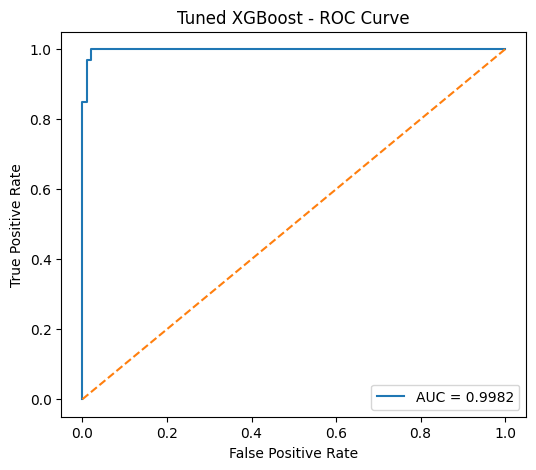

In [18]:
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

print("Best XGB Parameters:", xgb_random.best_params_)

evaluate_model(best_xgb, X_test, y_test, "Tuned XGBoost")

## 1️⃣5️⃣ Final Model Selection

In [19]:
tuned_results = {
    "Tuned Random Forest": get_metrics(best_rf, X_test, y_test),
    "Tuned XGBoost": get_metrics(best_xgb, X_test, y_test)
}

tuned_comparison_df = pd.DataFrame(tuned_results).T

tuned_comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Tuned Random Forest,0.959799,0.950980,0.97,0.960396,0.996263
Tuned XGBoost,0.984925,0.980198,0.99,0.985075,0.998182


In [20]:
best_model_name = tuned_comparison_df["F1"].idxmax()

print("Best model after tuning:", best_model_name)

if best_model_name == "Tuned Random Forest":
    final_model = best_rf
else:
    final_model = best_xgb

Best model after tuning: Tuned XGBoost


## The Final Metrics


===== Final Selected Model Evaluation =====
Accuracy: 0.9849246231155779
Precision: 0.9801980198019802
Recall: 0.99
F1 Score: 0.9850746268656716
ROC-AUC: 0.9981818181818182

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        99
           1       0.98      0.99      0.99       100

    accuracy                           0.98       199
   macro avg       0.98      0.98      0.98       199
weighted avg       0.98      0.98      0.98       199



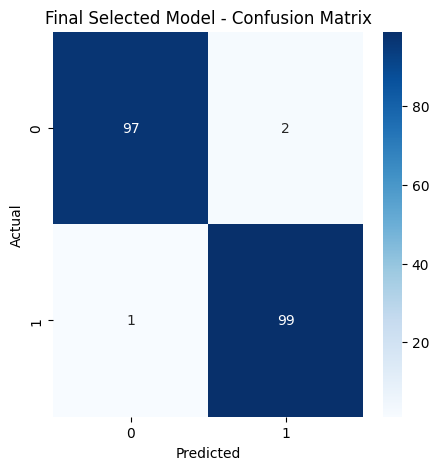

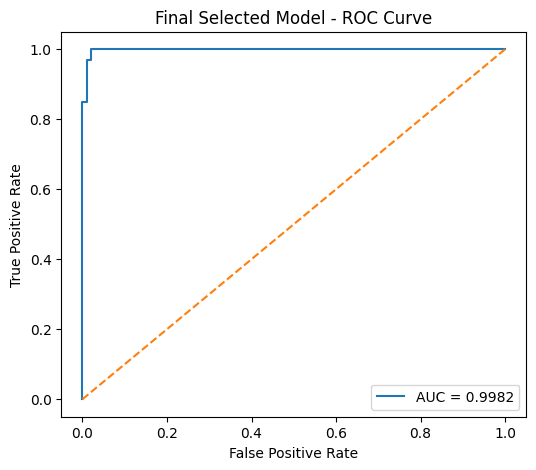

In [21]:
evaluate_model(final_model, X_test, y_test, "Final Selected Model")

## Saving Final Evaluation Results

In [22]:
final_metrics = get_metrics(final_model, X_test, y_test)

metrics_df = pd.DataFrame([final_metrics])

metrics_df.to_csv(
    os.path.join(report_path, "final_model_metrics.csv"),
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.984925,0.980198,0.99,0.985075,0.998182


## Final Model Selection - Theory

After performing hyperparameter tuning, Random Forest and XGBoost were compared based on evaluation metrics including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Among the models, the one with the highest F1-score and strong recall performance was selected as the final model for predicting exoplanet habitability.

The selected model demonstrates strong predictive capability while maintaining balanced precision and recall, making it suitable for identifying potentially habitable exoplanets.

## 1️⃣6️⃣ Save Final Model

In [23]:
import os
import joblib

# Define model folder
model_dir = "D:/Desktop/B13-ExoHabitAI/models"

# Create folder if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save final trained model
joblib.dump(
    final_model,
    f"{model_dir}/exohabit_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## 1️⃣7️⃣ Feature Importance Analysis

Top 10 Most Important Features:


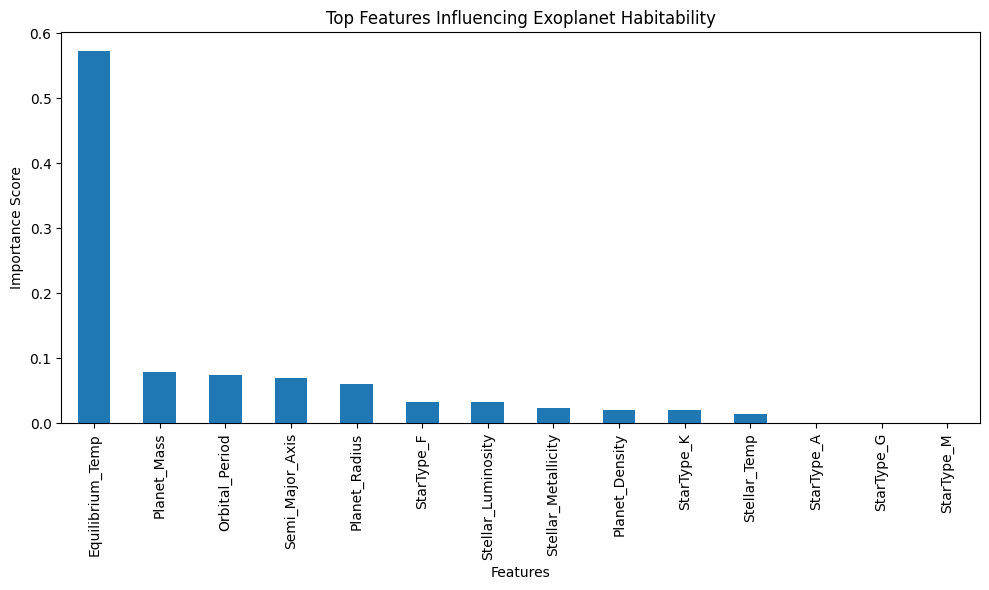

In [24]:
# Extract feature importance from final model
importances = final_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

# Display top important features (table)
print("Top 10 Most Important Features:")
feature_importance.head(10)

feature_importance.head(10).to_csv(
    os.path.join(report_path, "feature_importance_table.csv")
)

# Plot
plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind="bar")

plt.title("Top Features Influencing Exoplanet Habitability")
plt.ylabel("Importance Score")
plt.xlabel("Features")

plt.tight_layout()

plt.savefig(os.path.join(report_path, "feature_importance.png"))

plt.show()


## Feature Importance Interpretation

The feature importance analysis reveals which planetary and stellar attributes most strongly influence habitability predictions.

Features such as planetary radius, stellar flux, equilibrium temperature, and orbital characteristics tend to dominate the prediction process. These factors are scientifically meaningful because they directly affect the ability of a planet to support liquid water and maintain stable environmental conditions.

Higher stellar flux and moderate equilibrium temperatures indicate favorable energy conditions for habitability, while planetary size influences atmospheric retention and surface gravity.

Thus, the model’s learned feature importance aligns with known astrophysical principles governing planetary habitability.

## 1️⃣8️⃣ Generate Final Habitability Ranking

In [25]:
# Retrain final model on full dataset
final_model.fit(X, y)

# Generate probability scores
df["Habitability_Probability"] = final_model.predict_proba(X)[:,1]

# Rank planets
df_ranked = df.sort_values(
    by="Habitability_Probability",
    ascending=False
)

# Save
output_path = "D:/Desktop/B13-ExoHabitAI/data/processed/habitability_ranked.csv"

df_ranked.to_csv(output_path, index=False)

print("Habitability ranking saved successfully!")

df_ranked.head()

Habitability ranking saved successfully!


,Planet_Name,Planet_Radius,Planet_Mass,Orbital_Period,Semi_Major_Axis,Equilibrium_Temp,Planet_Density,Stellar_Temp,Stellar_Luminosity,Stellar_Metallicity,Habitability_Score_Index,Stellar_Compatibility_Index,Orbital_Stability_Factor,StarType_A,StarType_F,StarType_G,StarType_K,StarType_M,Target_Habitable,Habitability_Probability
216,HIP 116454 b,2.469,9.70,9.100416,0.0792,753.2,3.53,5048.0,0.336403,0.00,0.226878,0.888321,0.096592,False,False,False,True,False,1,0.999981
682,TOI-283 b,2.340,6.54,17.617450,0.1230,661.0,2.81,5213.0,0.460002,-0.09,0.284991,0.931519,0.096944,False,False,False,True,False,1,0.999980
640,TOI-2345 c,2.451,7.27,21.064302,0.1257,544.0,2.71,4687.0,0.271434,-0.10,0.353420,0.767584,0.223820,False,False,False,True,False,1,0.999980
513,TOI-125 c,2.759,6.63,9.150590,0.0814,827.8,1.73,5320.0,0.519003,-0.02,0.190613,0.954456,0.065731,False,False,False,True,False,1,0.999980
859,TOI-757 b,2.500,10.50,17.468190,0.1220,641.0,3.60,5278.0,0.420001,-0.27,0.289462,0.945959,0.100187,False,False,False,True,False,1,0.999980


## 1️⃣9️⃣ Cross-Validation Performance

In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Cross Validation F1 Scores:", cv_scores)
print("Average F1 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

print("Cross Validation F1 Scores:", cv_scores)

Cross Validation F1 Scores: [0.98989899 0.93779904 0.94472362 0.97058824 0.97938144]
Average F1 Score: 0.9644782659289459
Standard Deviation: 0.020038346601070792
Cross Validation F1 Scores: [0.98989899 0.93779904 0.94472362 0.97058824 0.97938144]


## Cross-Validation Analysis

To ensure the stability and reliability of the selected model, 5-fold cross-validation was performed on the complete dataset.

The cross-validation results show that the model maintains consistent F1-scores across different data splits, indicating strong generalization capability and minimal overfitting.

This confirms that the selected model is robust for predicting exoplanet habitability.